In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib plotly

#**STREAMLIT WEBLINK:**

 https://shopper-spectrum-utluznvxwuxnwxzpo4vnr2.streamlit.app/

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import joblib

In [ ]:
df = pd.read_csv("online_retail.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df_sample = df.sample(n=100000, random_state=42)

df_sample.to_csv(
    "online_retail_sample.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("online_retail_sample.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.dropna(subset=["CustomerID"], inplace=True)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["CustomerID"] = df["CustomerID"].astype(int)

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


<Axes: xlabel='Country'>

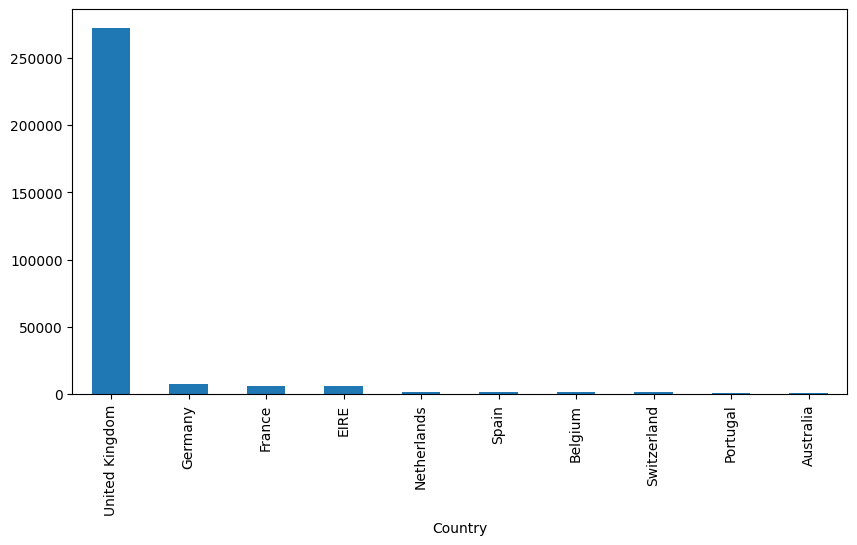

In [ ]:
country_sales = df.groupby("Country")["InvoiceNo"].count().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', figsize=(10,5))

<Axes: xlabel='Description'>

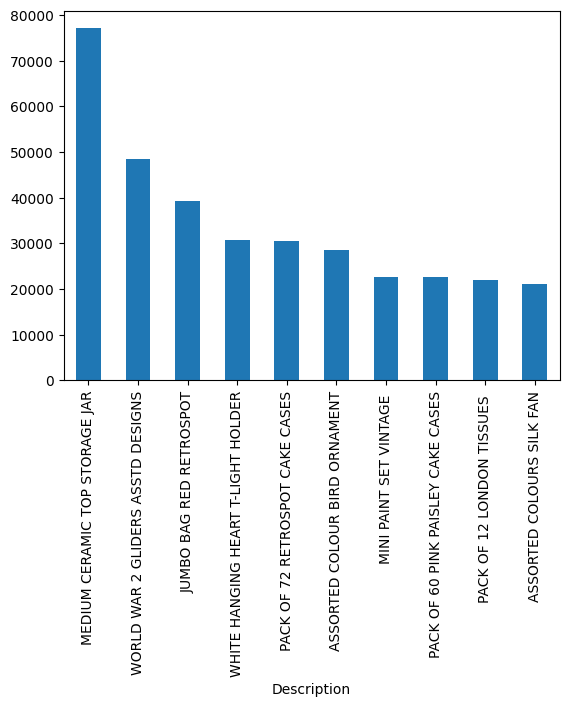

In [ ]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

<Axes: xlabel='Month'>

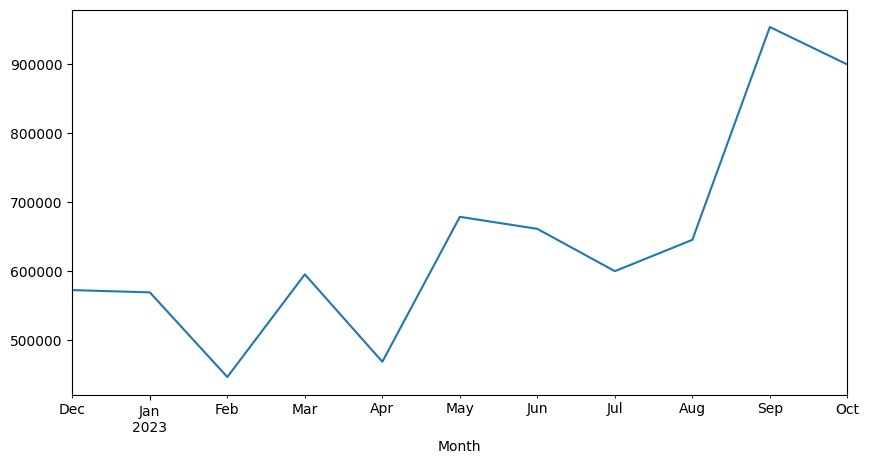

In [ ]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalAmount"].sum()

monthly_sales.plot(figsize=(10,5))

<Axes: xlabel='InvoiceDate'>

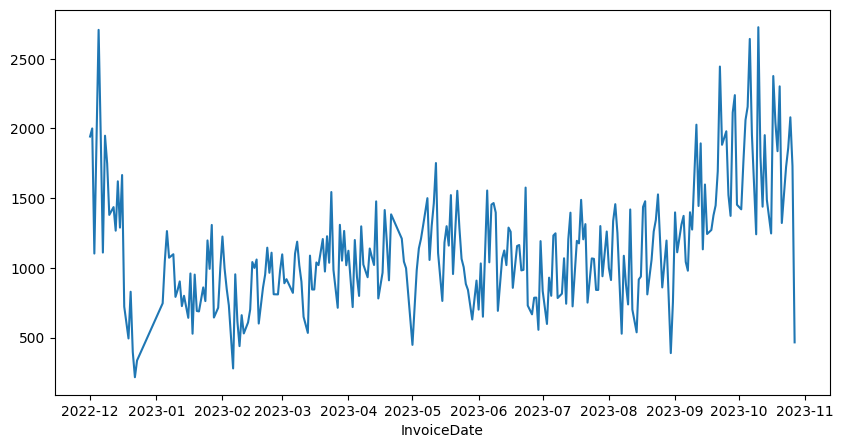

In [ ]:
daily = df.groupby(df["InvoiceDate"].dt.date)["InvoiceNo"].count()

daily.plot(figsize=(10,5))

<Axes: >

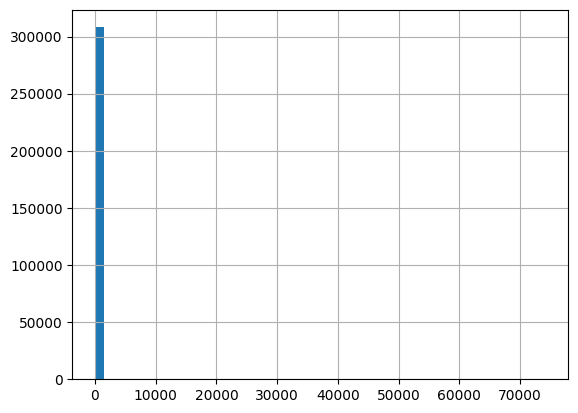

In [ ]:
df["Quantity"].hist(bins=50)

<Axes: >

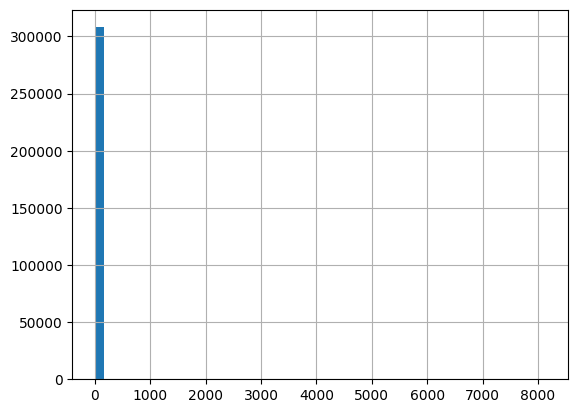

In [ ]:
df["UnitPrice"].hist(bins=50)

<Axes: >

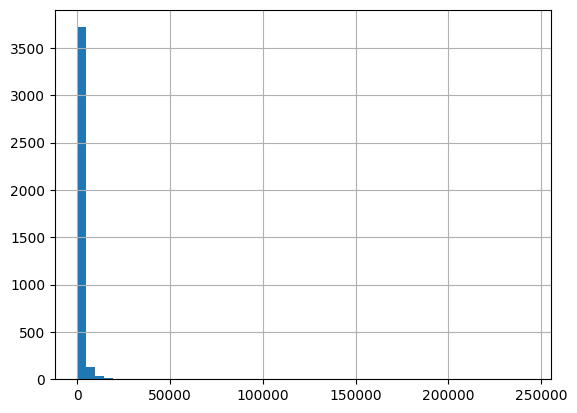

In [ ]:
customer_money = df.groupby("CustomerID")["TotalAmount"].sum()

customer_money.hist(bins=50)

<Axes: xlabel='CustomerID'>

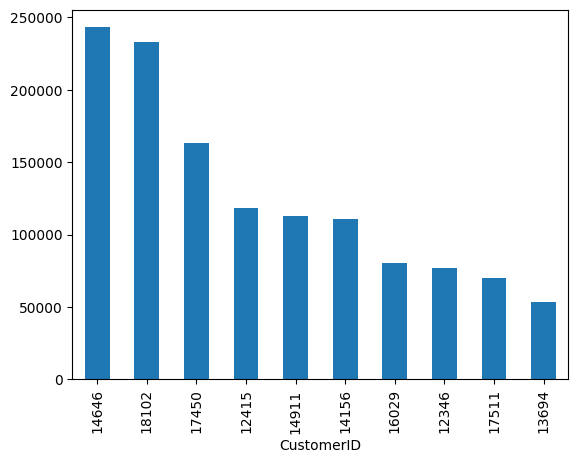

In [ ]:
top_customers = customer_money.sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x:(snapshot_date-x.max()).days,
    "InvoiceNo":"nunique",
    "TotalAmount":"sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,283,1,77183.60
12347,87,5,2790.86
12348,32,4,1797.24
12350,267,1,334.40
12352,29,7,2194.31


<Axes: >

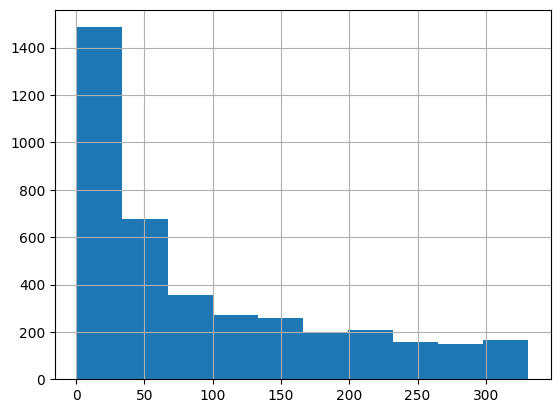

In [ ]:
rfm["Recency"].hist()

<Axes: >

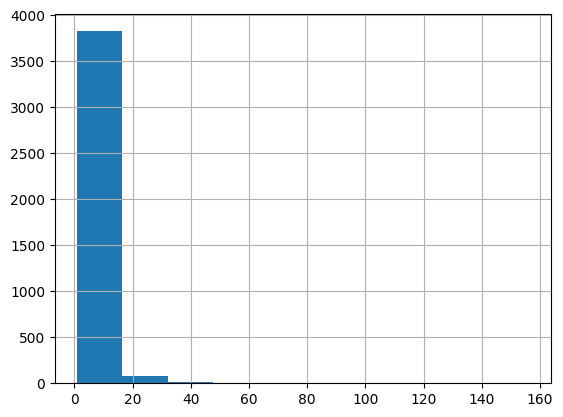

In [ ]:
rfm["Frequency"].hist()

<Axes: >

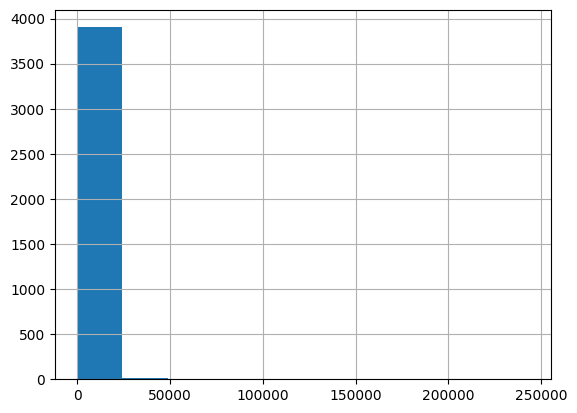

In [ ]:
rfm["Monetary"].hist()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

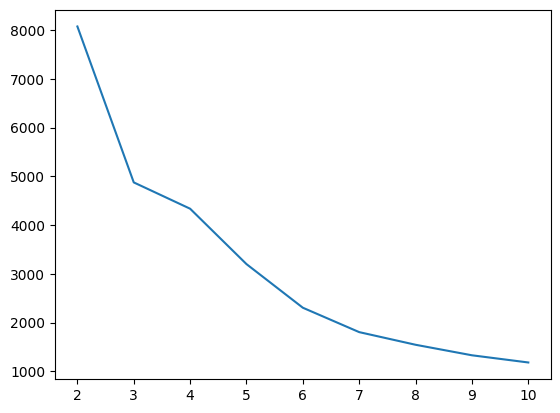

In [ ]:
from sklearn.cluster import KMeans

inertia=[]

for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,11),inertia)

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42)

    labels = km.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(k, score)

2 0.8922558104650232
3 0.5585338688909313
4 0.4197049336897123
5 0.42291238456166697
6 0.5010678402100621
7 0.5035657542932622


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [ ]:
cluster_map = {
    0:"High Value",
    1:"Regular",
    2:"Occasional",
    3:"At Risk"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_map)

<Axes: xlabel='Frequency', ylabel='Monetary'>

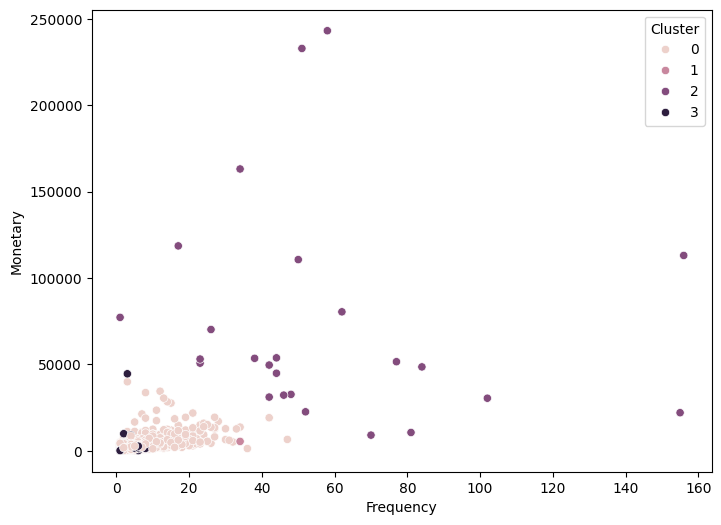

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm["Frequency"],
    y=rfm["Monetary"],
    hue=rfm["Cluster"]
)

In [ ]:
customer_product = pd.pivot_table(
    df,
    index="CustomerID",
    columns="Description",
    values="Quantity",
    fill_value=0
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    customer_product.T
)

similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

<Axes: xlabel='Description', ylabel='Description'>

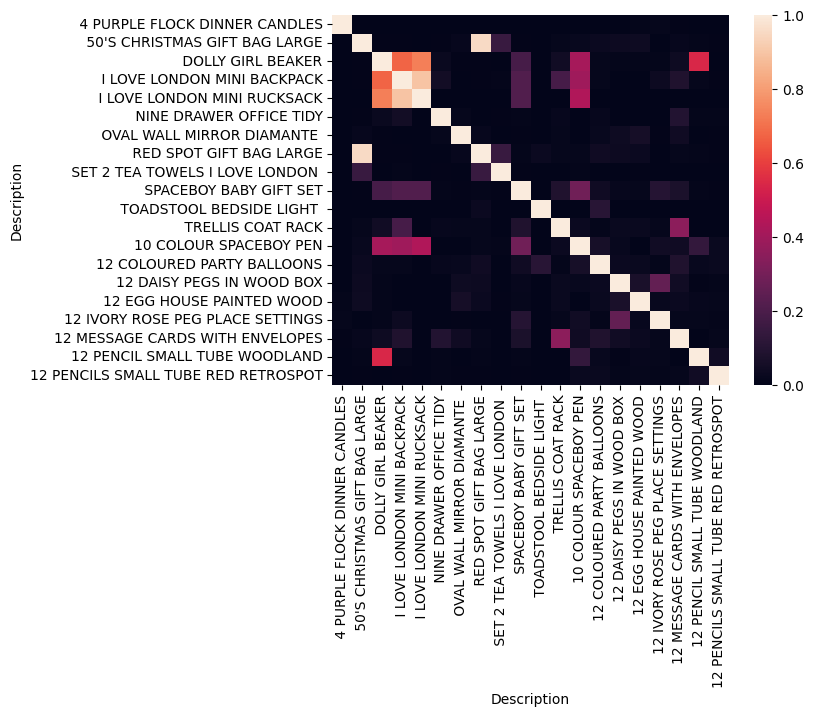

In [ ]:
sns.heatmap(similarity_df.iloc[:20,:20])

In [ ]:
def recommend(product_name):

    if product_name not in similarity_df.columns:
        return []

    recs = similarity_df[product_name]\
            .sort_values(ascending=False)\
            .iloc[1:6]

    return recs.index.tolist()

recommend("GREEN VINTAGE SPOT BEAKER")

['PINK VINTAGE SPOT BEAKER',
 'BLUE VINTAGE SPOT BEAKER',
 'PANTRY CHOPPING BOARD',
 'POTTING SHED CANDLE CITRONELLA',
 'POTTING SHED ROSE CANDLE']

In [ ]:
import joblib

joblib.dump(kmeans,"kmeans_model.pkl")

joblib.dump(scaler,"scaler.pkl")

joblib.dump(similarity_df,"product_similarity.pkl")

joblib.dump(
    similarity_df.columns.tolist(),
    "product_names.pkl"
)

['product_names.pkl']

In [ ]:
import pandas as pd
import joblib

# Reduce precision further
similarity_df = similarity_df.astype("float16")

# Save with maximum compression
joblib.dump(
    similarity_df,
    "product_similarity.pkl",
    compress=("gzip", 9)
)

['product_similarity.pkl']

In [ ]:
from google.colab import files

files.download("kmeans_model.pkl")
files.download("scaler.pkl")
files.download("product_similarity.pkl")
files.download("product_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>